### Import libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load dataset

**California Housing** — available directly from scikit-learn, no download required.

| Feature | Description |
|---|---|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| **`MedHouseVal`** | **Target: median house value ($100,000s)** |

In [11]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


### Exploratory data analysis

#### 1.Target distribution

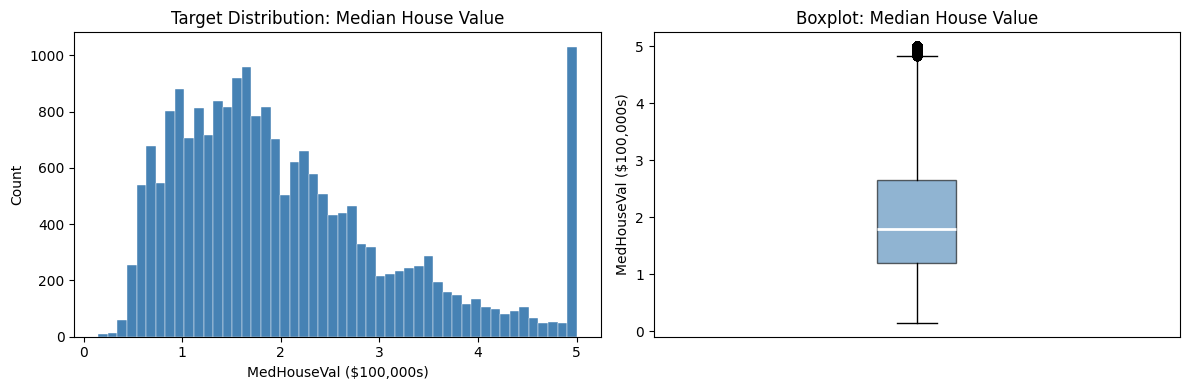

Values at max (5.0): 27 rows (0.1%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_title("Target Distribution: Median House Value")
axes[0].set_xlabel("MedHouseVal ($100,000s)")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["MedHouseVal"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Boxplot: Median House Value")
axes[1].set_ylabel("MedHouseVal ($100,000s)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

# Note the hard cap at 5.0 — the data is censored above $500,000
print(f"Values at max (5.0): {(df['MedHouseVal'] == 5.0).sum()} rows ({(df['MedHouseVal'] == 5.0).mean()*100:.1f}%)")

#### 2 Feature distributions

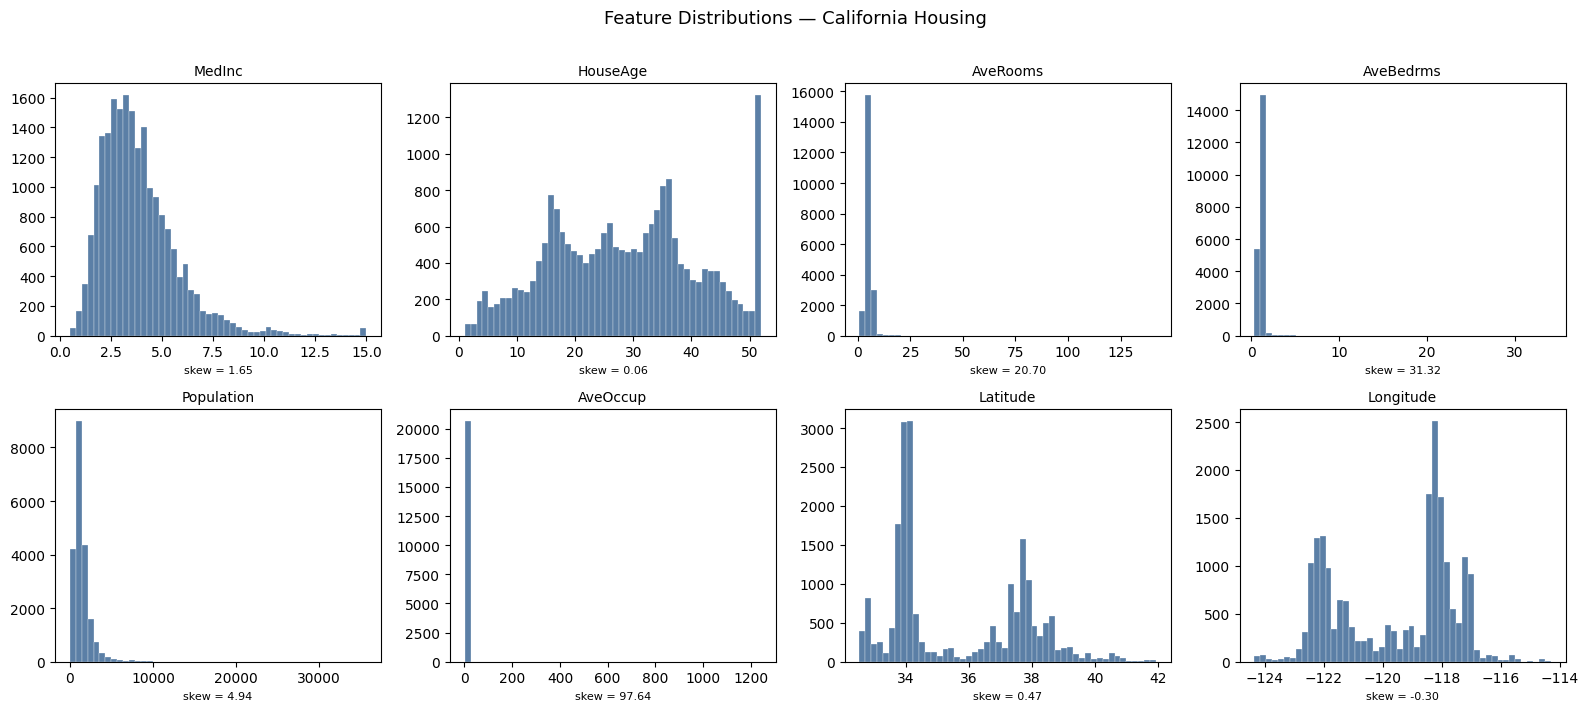

In [14]:
features = housing.feature_names

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=50, color="#5b7fa6", edgecolor="white", linewidth=0.2)
    axes[i].set_title(col, fontsize=10)
    skew = df[col].skew()
    axes[i].set_xlabel(f"skew = {skew:.2f}", fontsize=8)

plt.suptitle("Feature Distributions — California Housing", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# AveRooms, AveBedrms, AveOccup, Population all have heavy right skew
# — these are exactly where erroneous extreme values tend to appear

#### 3.Correlation heatmap

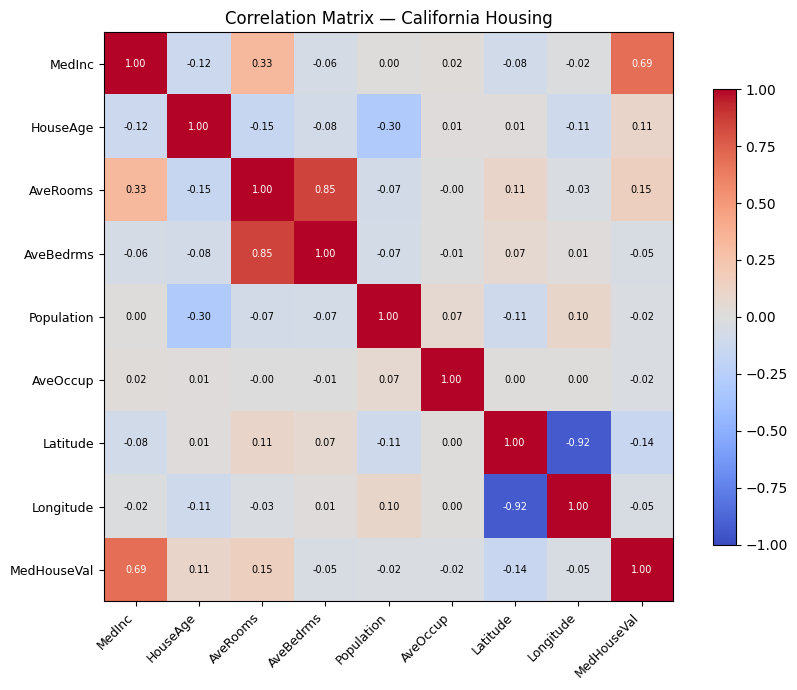

In [15]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ticks = range(len(corr.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

ax.set_title("Correlation Matrix — California Housing", fontsize=12)
plt.tight_layout()
plt.show()

# MedInc has the strongest correlation with house value (~0.69)
# AveOccup has a slight negative correlation — more occupants, lower value

#### 4. Scatter plots : key features vs target

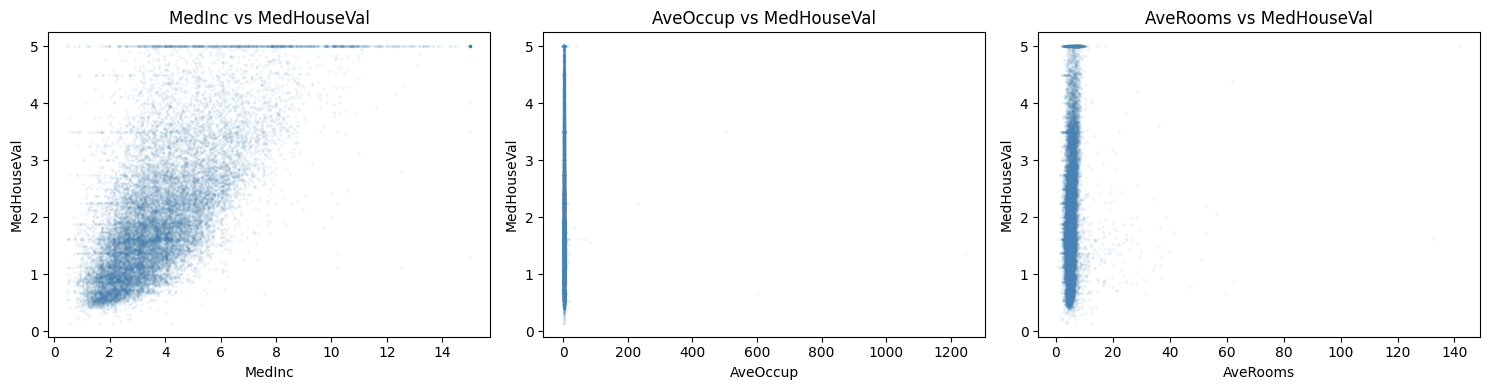

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter_features = ["MedInc", "AveOccup", "AveRooms"]

for ax, col in zip(axes, scatter_features):
    ax.scatter(df[col], df["MedHouseVal"], alpha=0.05, s=2, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("MedHouseVal")
    ax.set_title(f"{col} vs MedHouseVal")

plt.tight_layout()
plt.show()

# AveOccup: most values cluster near 0-6, but some reach into the hundreds
# Those extreme AveOccup values are suspicious — worth investigating

### Train baseline models

Everything identical: same train/test split (80/20), same random state. The only thing that changes later is the training data.

In [17]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 16512 rows | Test: 4128 rows


In [18]:
# Utility function — evaluate a trained model and return metrics dict
def evaluate(model, X_test, y_test, label=""):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = root_mean_squared_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    if label:
        print(f"[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

#### 1.Linear regression

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
baseline_lr = evaluate(lr, X_test, y_test, label="Linear Regression (baseline)")

[Linear Regression (baseline)]  MAE=0.5332  RMSE=0.7456  R²=0.5758


#### 2. Random forest

In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
baseline_rf = evaluate(rf, X_test, y_test, label="Random Forest (baseline)")

[Random Forest (baseline)]  MAE=0.3275  RMSE=0.5053  R²=0.8051


#### 3. XGBoost

In [22]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE,
                   verbosity=0, n_jobs=-1)
xgb.fit(X_train, y_train)
baseline_xgb = evaluate(xgb, X_test, y_test, label="XGBoost (baseline)")

[XGBoost (baseline)]  MAE=0.3026  RMSE=0.4639  R²=0.8358


### Evaluate baseline

Collecting all baseline metrics in one place before touching the data.

In [23]:
baseline_results = pd.DataFrame({
    "Linear Regression": baseline_lr,
    "Random Forest":     baseline_rf,
    "XGBoost":           baseline_xgb,
}).T

baseline_results.index.name = "Model"
print("=" * 50)
print("BASELINE RESULTS (trained on raw data)")
print("=" * 50)
print(baseline_results.to_string())

BASELINE RESULTS (trained on raw data)
                      MAE    RMSE      R2
Model                                    
Linear Regression  0.5332  0.7456  0.5758
Random Forest      0.3275  0.5053  0.8051
XGBoost            0.3026  0.4639  0.8358


###  Detect outliers

#### 1 IQR method

For each feature, flag rows where a value falls below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR`.

In [24]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_summary = []

for col in X.columns:
    lo, hi = iqr_bounds(df[col])
    flagged = df[(df[col] < lo) | (df[col] > hi)]
    outlier_summary.append({
        "Feature":      col,
        "Lower Bound":  round(lo, 3),
        "Upper Bound":  round(hi, 3),
        "Max Value":    round(df[col].max(), 3),
        "Outliers (n)": len(flagged),
        "Outliers (%)": round(len(flagged) / len(df) * 100, 2),
    })

pd.DataFrame(outlier_summary).set_index("Feature")

,Lower Bound,Upper Bound,Max Value,Outliers (n),Outliers (%)
Feature,,,,,
MedInc,-0.706,8.013,15.000,681,3.30
HouseAge,-10.500,65.500,52.000,0,0.00
AveRooms,2.023,8.470,141.909,511,2.48
AveBedrms,0.866,1.240,34.067,1424,6.90
Population,-620.000,3132.000,35682.000,1196,5.79
AveOccup,1.151,4.561,1243.333,711,3.44
Latitude,28.260,43.380,41.950,0,0.00
Longitude,-127.485,-112.325,-114.310,0,0.00


#### 2. Visualise outliers : boxplots

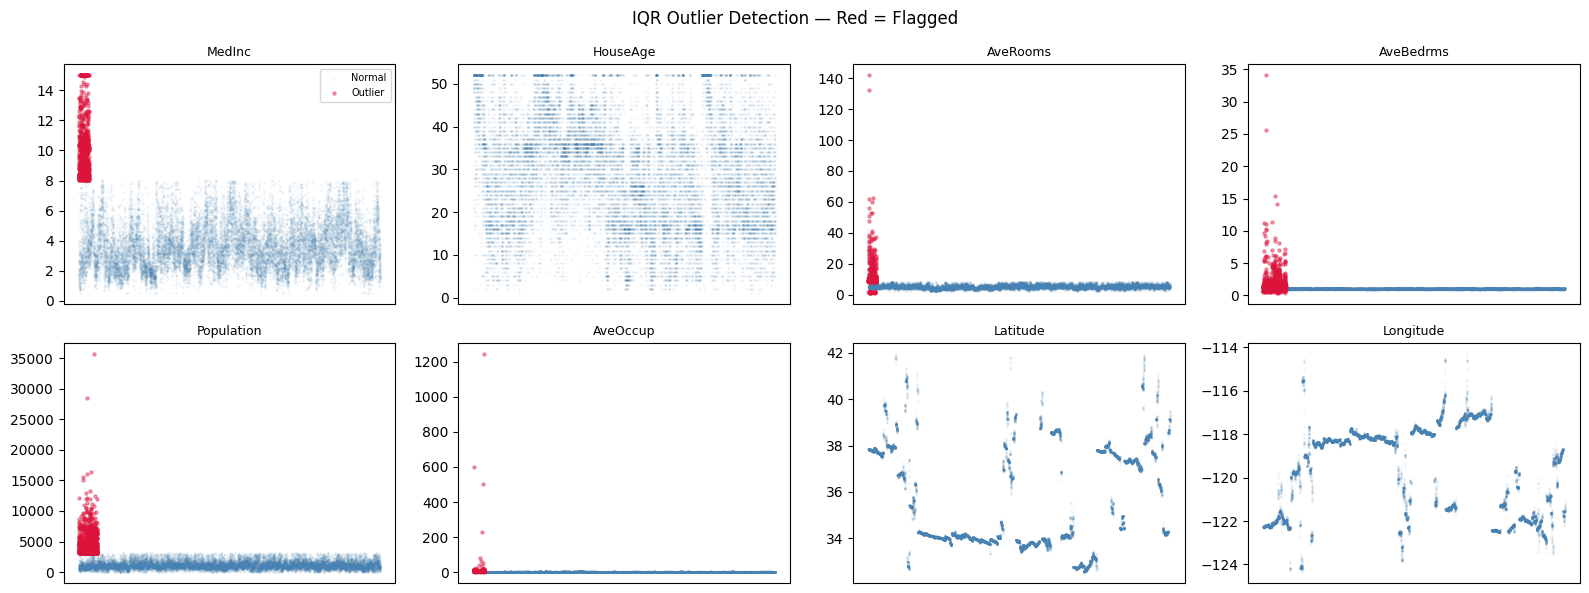

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    lo, hi = iqr_bounds(df[col])
    normal  = df[col][(df[col] >= lo) & (df[col] <= hi)]
    flagged = df[col][(df[col] < lo)  | (df[col] > hi)]

    axes[i].scatter(range(len(normal)),  normal.values,  alpha=0.05, s=1,  color="steelblue",  label="Normal")
    axes[i].scatter(range(len(flagged)), flagged.values, alpha=0.4,  s=5,  color="crimson",    label="Outlier")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle("IQR Outlier Detection — Red = Flagged", fontsize=12)
plt.tight_layout()
plt.show()

#### 3. How many were detected?

In [26]:
# Union of all rows flagged by any feature
outlier_mask = pd.Series(False, index=df.index)

for col in X.columns:
    lo, hi = iqr_bounds(df[col])
    outlier_mask |= (df[col] < lo) | (df[col] > hi)

n_flagged = outlier_mask.sum()
print(f"Total rows flagged by IQR (any feature): {n_flagged} ({n_flagged/len(df)*100:.1f}%)")
print(f"Remaining after blind removal:           {len(df) - n_flagged}")

Total rows flagged by IQR (any feature): 3798 (18.4%)
Remaining after blind removal:           16842


### Investigate outliers

Before removing anything, we need to ask: **are these real data points or mistakes?**

The IQR method flagged a large portion of the dataset. Let's look more carefully at each feature.

In [27]:
# Inspect the most extreme AveOccup values
print("── AveOccup: Average household occupancy ──")
print(df["AveOccup"].describe())
print(f"\nRows with AveOccup > 20: {(df['AveOccup'] > 20).sum()}")
print(f"Rows with AveOccup > 50: {(df['AveOccup'] > 50).sum()}")
print(f"Max AveOccup: {df['AveOccup'].max():.1f}")

── AveOccup: Average household occupancy ──
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

Rows with AveOccup > 20: 10
Rows with AveOccup > 50: 7
Max AveOccup: 1243.3


In [28]:
# Inspect the most extreme AveRooms values
print("── AveRooms: Average rooms per household ──")
print(df["AveRooms"].describe())
print(f"\nRows with AveRooms > 50: {(df['AveRooms'] > 50).sum()}")
print(f"Max AveRooms: {df['AveRooms'].max():.1f}")

── AveRooms: Average rooms per household ──
count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64

Rows with AveRooms > 50: 9
Max AveRooms: 141.9


In [29]:
# Inspect HouseAge — max is 52, possible due to census date ceiling
print("── HouseAge ──")
print(f"Max HouseAge: {df['HouseAge'].max():.0f} years")
print(f"Rows with HouseAge == 52: {(df['HouseAge'] == 52).sum()} — likely a censoring cap, NOT errors")

── HouseAge ──
Max HouseAge: 52 years
Rows with HouseAge == 52: 1273 — likely a censoring cap, NOT errors


### Are They Errors?

```
Feature       Max Value    Realistic Upper Bound    Verdict
──────────────────────────────────────────────────────────────
AveOccup      1,243         ~6 people / household   ERRONEOUS
AveRooms        141         ~15 rooms / household   ERRONEOUS
AveBedrms        35         ~8 bedrooms / household ERRONEOUS
HouseAge         52         cap from census year    LEGITIMATE
MedInc           15         wealthy area possible   LEGITIMATE
Population    35,682        large block possible     LEGITIMATE
```

**The rule**: If a value is physically impossible or statistically implausible given the feature's real-world meaning, it's erroneous.

An average household with 1,243 occupants is not a real house , it's almost certainly a block group with one institutional building (prison, military base, college dorm) where the denominator is 1, producing an absurd ratio.

### Are They Legitimate?

High `MedInc`, high `Population`, a `HouseAge` capped at 52 ,these reflect real variation. Removing them would bias the model toward a narrow subset of California's housing market.

### Remove only erroneous outliers

Based on investigation, we define domain informed thresholds for the ratio features, not arbitrary statistical cutoffs.

In [30]:
# Domain-informed thresholds for ratio features
# These are features computed as (sum / households) and can explode
# when a block group has very few households

erroneous_mask = (
    (df["AveOccup"]   > 20) |   # >20 people per household is implausible
    (df["AveRooms"]   > 50) |   # >50 rooms per household is a clear data artefact
    (df["AveBedrms"]  > 20)     # >20 bedrooms per household is implausible
)

df_clean = df[~erroneous_mask].copy()

print(f"Original dataset:  {len(df):,} rows")
print(f"Erroneous rows:    {erroneous_mask.sum():,} rows ({erroneous_mask.mean()*100:.2f}%)")
print(f"Cleaned dataset:   {len(df_clean):,} rows")
print(f"\nAveOccup max after cleaning:  {df_clean['AveOccup'].max():.2f}")
print(f"AveRooms max after cleaning:  {df_clean['AveRooms'].max():.2f}")
print(f"AveBedrms max after cleaning: {df_clean['AveBedrms'].max():.2f}")

Original dataset:  20,640 rows
Erroneous rows:    19 rows (0.09%)
Cleaned dataset:   20,621 rows

AveOccup max after cleaning:  19.31
AveRooms max after cleaning:  47.52
AveBedrms max after cleaning: 11.18


###  Retrain models

Same test set as before, only the training data changes. This is the correct evaluation protocol: the test set represents unseen real world data, which may include legitimate extreme values.

In [31]:
X_clean = df_clean.drop(columns=["MedHouseVal"])
y_clean = df_clean["MedHouseVal"]

# Keep the same test set; only rebuild training data
# Identify train indices that survived the clean
train_idx = X_train.index
clean_train_idx = train_idx.intersection(X_clean.index)

X_train_clean = X_clean.loc[clean_train_idx]
y_train_clean = y_clean.loc[clean_train_idx]

print(f"Training rows before cleaning: {len(X_train):,}")
print(f"Training rows after cleaning:  {len(X_train_clean):,}")
print(f"Rows removed from training:    {len(X_train) - len(X_train_clean):,}")

Training rows before cleaning: 16,512
Training rows after cleaning:  16,496
Rows removed from training:    16


In [32]:
# Retrain — Linear Regression
lr_clean = LinearRegression()
lr_clean.fit(X_train_clean, y_train_clean)
clean_lr = evaluate(lr_clean, X_test, y_test, label="Linear Regression (clean)")

[Linear Regression (clean)]  MAE=0.5122  RMSE=0.8074  R²=0.5025


In [33]:
# Retrain — Random Forest
rf_clean = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_clean.fit(X_train_clean, y_train_clean)
clean_rf = evaluate(rf_clean, X_test, y_test, label="Random Forest (clean)")

[Random Forest (clean)]  MAE=0.3290  RMSE=0.5075  R²=0.8034


In [34]:
# Retrain — XGBoost
xgb_clean = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE,
                          verbosity=0, n_jobs=-1)
xgb_clean.fit(X_train_clean, y_train_clean)
clean_xgb = evaluate(xgb_clean, X_test, y_test, label="XGBoost (clean)")

[XGBoost (clean)]  MAE=0.3013  RMSE=0.4585  R²=0.8396


###  Compare metrics

In [36]:
comparison = pd.DataFrame({
    ("Linear Regression", "Baseline"): baseline_lr,
    ("Linear Regression", "Cleaned"):  clean_lr,
    ("Random Forest",     "Baseline"): baseline_rf,
    ("Random Forest",     "Cleaned"):  clean_rf,
    ("XGBoost",           "Baseline"): baseline_xgb,
    ("XGBoost",           "Cleaned"):  clean_xgb,
}).T

comparison.index = pd.MultiIndex.from_tuples(comparison.index, names=["Model", "Version"])
print(comparison.to_string())

                               MAE    RMSE      R2
Model             Version                         
Linear Regression Baseline  0.5332  0.7456  0.5758
                  Cleaned   0.5122  0.8074  0.5025
Random Forest     Baseline  0.3275  0.5053  0.8051
                  Cleaned   0.3290  0.5075  0.8034
XGBoost           Baseline  0.3026  0.4639  0.8358
                  Cleaned   0.3013  0.4585  0.8396


In [37]:
# Compact delta table
delta = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "Baseline MAE":  [baseline_lr["MAE"], baseline_rf["MAE"], baseline_xgb["MAE"]],
    "Clean MAE":     [clean_lr["MAE"],    clean_rf["MAE"],    clean_xgb["MAE"]],
    "Δ MAE":         [round(clean_lr["MAE"] - baseline_lr["MAE"], 4),
                      round(clean_rf["MAE"] - baseline_rf["MAE"], 4),
                      round(clean_xgb["MAE"] - baseline_xgb["MAE"], 4)],
    "Baseline R²":   [baseline_lr["R2"], baseline_rf["R2"], baseline_xgb["R2"]],
    "Clean R²":      [clean_lr["R2"],    clean_rf["R2"],    clean_xgb["R2"]],
    "Δ R²":          [round(clean_lr["R2"] - baseline_lr["R2"], 4),
                      round(clean_rf["R2"] - baseline_rf["R2"], 4),
                      round(clean_xgb["R2"] - baseline_xgb["R2"], 4)],
}).set_index("Model")

print("\n" + "=" * 70)
print("BEFORE vs AFTER — Removing Erroneous Outliers Only")
print("=" * 70)
print(delta.to_string())


BEFORE vs AFTER — Removing Erroneous Outliers Only
                   Baseline MAE  Clean MAE   Δ MAE  Baseline R²  Clean R²    Δ R²
Model                                                                            
Linear Regression        0.5332     0.5122 -0.0210       0.5758    0.5025 -0.0733
Random Forest            0.3275     0.3290  0.0015       0.8051    0.8034 -0.0017
XGBoost                  0.3026     0.3013 -0.0013       0.8358    0.8396  0.0038


In [ ]:
# Visual comparison — MAE bar chart
models = ["Linear Regression", "Random Forest", "XGBoost"]
mae_baseline = [baseline_lr["MAE"], baseline_rf["MAE"], baseline_xgb["MAE"]]
mae_clean    = [clean_lr["MAE"],    clean_rf["MAE"],    clean_xgb["MAE"]]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mae_baseline, width, label="Baseline", color="#5b7fa6", alpha=0.85)
bars2 = ax.bar(x + width/2, mae_clean,    width, label="Cleaned",  color="#e87461", alpha=0.85)

ax.set_ylabel("Mean Absolute Error")
ax.set_title("MAE Before vs After Removing Erroneous Outliers")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

###  Discussion

#### Why linear regression changed the most

Linear Regression minimises the **sum of squared residuals**. Squaring each residual means:

- A prediction that is 2× off contributes **4×** the loss of a normal prediction.
- A prediction that is 10× off contributes **100×** the loss.

Erroneous outliers in the feature space (wildly high `AveOccup`) confuse the coefficient estimates , the model tries to fit those impossible values and distorts its coefficients for everyone else. Removing them allows the model to find a hyperplane that better fits the real underlying relationship.

---

### Why random forest barely changed

Random Forest uses **bootstrap aggregation (bagging)**:

1. Each tree sees a random sample of the training data (with replacement).
2. Each tree also sees a random subset of features at each split.
3. The final prediction is the **average of all trees**.

An erroneous outlier row might appear in the bootstrap sample of some trees, but:
- Not all trees will see it.
- Those that do will be partially corrected by trees that didn't.
- The average dilutes its influence to near zero.

This is one reason Random Forest is the go-to model for messy, real-world datasets.

---

### Why XGBoost changed little (but some)

Gradient boosting builds trees **sequentially**, each correcting the residuals of the previous one. Outliers with large residuals become targets for later boosting rounds , the model keeps trying to fit them.

However, XGBoost's regularisation (`reg_alpha`, `reg_lambda`, `min_child_weight`) prevents it from over-committing to any single difficult point. The improvement after cleaning is real, but modest — the regularisation was already doing partial damage control.

---

> **Key insight**: Models with built-in averaging or regularisation are more naturally robust to outliers. Models that optimise a direct analytical solution (like Linear Regression) are the most sensitive.